In [2]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-macosx_10_13_universal2.whl.metadata (8.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp312-cp312-macosx_11_0_arm6

In [3]:
import tensorflow as tf


In [1]:
MODEL_PATH = '../ml/weights/wound_unet_model.h5'


In [15]:
from tensorflow import keras
model = keras.models.load_model("../../ml/weights/wound_unet_model.h5", compile=False)

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [43]:
def preprocess(image):
    # Convert PIL to numpy array first for better performance
    img_array = np.array(image)
    
    # Use OpenCV for faster resizing
    resized = cv2.resize(img_array, (256, 256), interpolation=cv2.INTER_LINEAR)
    
    # Normalize in-place for better memory efficiency
    normalized = resized.astype(np.float32) / 255.0

    # shape: (H, W, C) → (1, H, W, C)
    image = np.expand_dims(normalized, axis=0)

    return image

In [47]:

from PIL import Image

# Load and preprocess the image
img_path = "../../uploads/image_8e8a0ed8c8e64733bbfa075190342c03.png"
image = Image.open(img_path).convert("RGB")
img = preprocess(image)

print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")

Image shape: (1, 256, 256, 3)
Image dtype: float32


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
Prediction shape: (1, 256, 256, 1)
Prediction dtype: float32


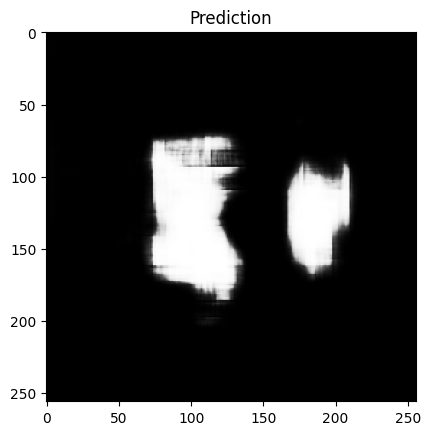

In [48]:
# Now predict with the preprocessed image
pred = model.predict(img)

print(f"Prediction shape: {pred.shape}")
print(f"Prediction dtype: {pred.dtype}")

plt.imshow(pred[0], cmap='gray')
plt.title("Prediction")
plt.show()